In [64]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [65]:
df = pd.read_csv("Leads.csv")

In [66]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [67]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [68]:
df.shape

(9240, 37)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [70]:
df.isna().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [71]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [78]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [79]:
df["country"].value_counts()

country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
Kuwait                     4
South Africa               4
Nigeria                    4
Germany                    4
Canada                     4
Sweden                     3
Italy                      2
Belgium                    2
Ghana                      2
Philippines                2
Netherlands                2
China                      2
Asia/Pacific Region        2
Bangladesh                 2
Uganda                     2
Russia                     1
Sri Lanka                  1
Tanzania                   1
Kenya                      1
Malaysia                   1
Liberia                    1
Denmar

In [80]:
df = df.drop(columns=["country"],axis=1)

In [81]:
df.columns

Index(['prospect_id', 'lead_number', 'lead_origin', 'lead_source',
       'do_not_email', 'do_not_call', 'converted', 'totalvisits',
       'total_time_spent_on_website', 'page_views_per_visit', 'last_activity',
       'specialization', 'how_did_you_hear_about_x_education',
       'what_is_your_current_occupation',
       'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine',
       'newspaper_article', 'x_education_forums', 'newspaper',
       'digital_advertisement', 'through_recommendations',
       'receive_more_updates_about_our_courses', 'tags', 'lead_quality',
       'update_me_on_supply_chain_content', 'get_updates_on_dm_content',
       'lead_profile', 'city', 'asymmetrique_activity_index',
       'asymmetrique_profile_index', 'asymmetrique_activity_score',
       'asymmetrique_profile_score',
       'i_agree_to_pay_the_amount_through_cheque',
       'a_free_copy_of_mastering_the_interview', 'last_notable_activity'],
      dtype='object')

In [82]:
for i in df.columns:
    df[i] = df[i].replace("Select",np.nan)


In [83]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

lead_source                                        36
totalvisits                                       137
page_views_per_visit                              137
last_activity                                     103
specialization                                   3380
how_did_you_hear_about_x_education               7250
what_is_your_current_occupation                  2690
what_matters_most_to_you_in_choosing_a_course    2709
tags                                             3353
lead_quality                                     4767
lead_profile                                     6855
city                                             3669
asymmetrique_activity_index                      4218
asymmetrique_profile_index                       4218
asymmetrique_activity_score                      4218
asymmetrique_profile_score                       4218
dtype: int64


In [84]:
drop_columns = ["how_did_you_hear_about_x_education","asymmetrique_activity_index","asymmetrique_profile_index","asymmetrique_activity_score","asymmetrique_profile_score"
                ,"lead_quality","lead_profile","city"]
df = df.drop(columns= drop_columns)

In [85]:
df.isna().sum()

prospect_id                                         0
lead_number                                         0
lead_origin                                         0
lead_source                                        36
do_not_email                                        0
do_not_call                                         0
converted                                           0
totalvisits                                       137
total_time_spent_on_website                         0
page_views_per_visit                              137
last_activity                                     103
specialization                                   3380
what_is_your_current_occupation                  2690
what_matters_most_to_you_in_choosing_a_course    2709
search                                              0
magazine                                            0
newspaper_article                                   0
x_education_forums                                  0
newspaper                   

In [87]:
df["tags"] = df["tags"].fillna("Not Specified")

In [96]:
tag_map = {
    # High Intent
    "will revert after reading the email": "high_intent",
    "closed by horizzon": "high_intent",
    "interested  in full time mba": "high_intent",
    "interested in next batch": "high_intent",
    "shall take in the next coming month": "high_intent",
    "still thinking": "high_intent",
    "in confusion whether part time or dlp": "high_intent",
    "want to take admission but has financial problems": "high_intent",
    
    # Unreachable
    "ringing": "unreachable",
    "switched off": "unreachable",
    "busy": "unreachable",
    "invalid number": "unreachable",
    "wrong number given": "unreachable",
    "opp hangup": "unreachable",
    "number not provided": "unreachable",
    
    # Lost or Ineligible
    "already a student": "lost_or_ineligible",
    "interested in other courses": "lost_or_ineligible",
    "lost to eins": "lost_or_ineligible",
    "not doing further education": "lost_or_ineligible",
    "graduation in progress": "lost_or_ineligible",
    "diploma holder (not eligible)": "lost_or_ineligible",
    "in touch with eins": "lost_or_ineligible",
    "lost to others": "lost_or_ineligible",
    "university not recognized": "lost_or_ineligible",
    "recognition issue (dec approval)": "lost_or_ineligible",
    "lateral student": "lost_or_ineligible",
    
    "not specified": "not_specified"
}

df["tags_grouped"] = df["tags"].str.lower().map(tag_map)

In [97]:
df["tags_grouped"].value_counts()

tags_grouped
not_specified         3353
high_intent           2571
unreachable           1819
lost_or_ineligible    1497
Name: count, dtype: int64

In [92]:
fillit = ["specialization",                                   
"what_is_your_current_occupation",                  
"what_matters_most_to_you_in_choosing_a_course"]    
df[fillit] = df[fillit].fillna("not_specified")

In [98]:
df.isna().sum()

prospect_id                                        0
lead_number                                        0
lead_origin                                        0
lead_source                                       36
do_not_email                                       0
do_not_call                                        0
converted                                          0
totalvisits                                      137
total_time_spent_on_website                        0
page_views_per_visit                             137
last_activity                                    103
specialization                                     0
what_is_your_current_occupation                    0
what_matters_most_to_you_in_choosing_a_course      0
search                                             0
magazine                                           0
newspaper_article                                  0
x_education_forums                                 0
newspaper                                     

In [99]:
df = df.dropna()

In [100]:
df.isna().sum()

prospect_id                                      0
lead_number                                      0
lead_origin                                      0
lead_source                                      0
do_not_email                                     0
do_not_call                                      0
converted                                        0
totalvisits                                      0
total_time_spent_on_website                      0
page_views_per_visit                             0
last_activity                                    0
specialization                                   0
what_is_your_current_occupation                  0
what_matters_most_to_you_in_choosing_a_course    0
search                                           0
magazine                                         0
newspaper_article                                0
x_education_forums                               0
newspaper                                        0
digital_advertisement          

In [106]:
df[(df["totalvisits"]<0) |
   (df["total_time_spent_on_website"]<0) |
   (df["page_views_per_visit"]<0)].shape[0]

0

In [107]:
df[(df["totalvisits"]==0)&
   (df["total_time_spent_on_website"])].shape[0]

0

In [108]:
df[(df["totalvisits"]==0)&
   (df["page_views_per_visit"])].shape[0]

0

In [109]:
df.head()

,prospect_id,lead_number,lead_origin,lead_source,do_not_email,do_not_call,converted,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,specialization,what_is_your_current_occupation,what_matters_most_to_you_in_choosing_a_course,search,magazine,newspaper_article,x_education_forums,newspaper,digital_advertisement,through_recommendations,receive_more_updates_about_our_courses,tags,update_me_on_supply_chain_content,get_updates_on_dm_content,i_agree_to_pay_the_amount_through_cheque,a_free_copy_of_mastering_the_interview,last_notable_activity,tags_grouped
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,not_specified,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,No,No,No,No,Modified,lost_or_ineligible
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,not_specified,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,No,No,Email Opened,unreachable
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,Business Administration,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,No,Yes,Email Opened,high_intent
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,No,No,Modified,unreachable
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,not_specified,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,No,No,Modified,high_intent


In [113]:
change = ["do_not_email","do_not_call","search","magazine","newspaper_article",
          	"x_education_forums","newspaper","digital_advertisement",
            "through_recommendations","receive_more_updates_about_our_courses",
            "update_me_on_supply_chain_content","get_updates_on_dm_content","i_agree_to_pay_the_amount_through_cheque",
            "a_free_copy_of_mastering_the_interview"]
df[change] = (df[change]=="Yes").astype("int")


In [117]:
for i in change:
    print(df[i].value_counts())

do_not_email
0    8358
1     716
Name: count, dtype: int64
do_not_call
0    9072
1       2
Name: count, dtype: int64
search
0    9060
1      14
Name: count, dtype: int64
magazine
0    9074
Name: count, dtype: int64
newspaper_article
0    9072
1       2
Name: count, dtype: int64
x_education_forums
0    9073
1       1
Name: count, dtype: int64
newspaper
0    9073
1       1
Name: count, dtype: int64
digital_advertisement
0    9070
1       4
Name: count, dtype: int64
through_recommendations
0    9067
1       7
Name: count, dtype: int64
receive_more_updates_about_our_courses
0    9074
Name: count, dtype: int64
update_me_on_supply_chain_content
0    9074
Name: count, dtype: int64
get_updates_on_dm_content
0    9074
Name: count, dtype: int64
i_agree_to_pay_the_amount_through_cheque
0    9074
Name: count, dtype: int64
a_free_copy_of_mastering_the_interview
0    6186
1    2888
Name: count, dtype: int64


In [118]:
cols_to_drop = [
    "magazine", 
    "receive_more_updates_about_our_courses",
    "update_me_on_supply_chain_content", 
    "get_updates_on_dm_content",
    "i_agree_to_pay_the_amount_through_cheque",
    "do_not_call", 
    "newspaper_article", 
    "x_education_forums", 
    "newspaper", 
    "digital_advertisement", 
    "through_recommendations", 
    "search"
]

df = df.drop(columns=cols_to_drop)

In [121]:
for_gd = ["lead_origin","lead_source","last_activity","specialization","what_is_your_current_occupation","what_matters_most_to_you_in_choosing_a_course","last_notable_activity"]
for i in for_gd:
    print(df[i].value_counts())

lead_origin
Landing Page Submission    4885
API                        3578
Lead Add Form               581
Lead Import                  30
Name: count, dtype: int64
lead_source
Google               2868
Direct Traffic       2543
Olark Chat           1753
Organic Search       1154
Reference             443
Welingak Website      129
Referral Sites        125
Facebook               31
bing                    6
google                  5
Click2call              4
Live Chat               2
Social Media            2
Press_Release           2
Pay per Click Ads       1
blog                    1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64
last_activity
Email Opened                    3432
SMS Sent                        2716
Olark Chat Conversation          972
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    312
Email Link Cli

In [122]:
lead_source_map = {
    # Search Engine
    "google": "search_engine", "google": "search_engine", "organic search": "search_engine", "bing": "search_engine",
    
    # Direct & Organic Inbound
    "direct traffic": "direct_inbound", "olark chat": "chat_inbound",
    
    # Referrals & Forms
    "reference": "referral", "referral sites": "referral", "welingak website": "referral",
    
    # Social Media
    "facebook": "social_media", "social media": "social_media", "youtubechannel": "social_media",
    
    # Marketing / Ads / Other Outbound
    "click2call": "other_marketing", "pay per click ads": "other_marketing", "press_release": "other_marketing",
    "nc_edm": "other_marketing", "live chat": "chat_inbound", "blog": "other_marketing", 
    "welearnblog_home": "other_marketing", "welearn": "other_marketing", "testone": "other_marketing"
}

df["lead_source_grouped"] = df["lead_source"].astype(str).str.lower().str.strip().map(lead_source_map).fillna("other")

In [123]:
activity_map = {
    #High Engagement
    "sms sent": "high_engagement",
    "converted to lead": "high_engagement",
    "had a phone conversation": "high_engagement",
    "approached upfront": "high_engagement",
    "visited booth in tradeshow": "high_engagement",
    "modified": "high_engagement",
    
    #Email / Digital Active
    "email opened": "digital_active",
    "email link clicked": "digital_active",
    "page visited on website": "digital_active",
    "form submitted on website": "digital_active",
    "olark chat conversation": "digital_active",
    "view in browser link clicked": "digital_active",
    "email received": "digital_active",
    "resubscribed to emails": "digital_active",
    
    #Lost / Unreachable
    "email bounced": "unreachable_or_lost",
    "unreachable": "unreachable_or_lost",
    "unsubscribed": "unreachable_or_lost",
    "email marked spam": "unreachable_or_lost"
}

df["last_activity_grouped"] = df["last_activity"].astype(str).str.lower().str.strip().map(activity_map).fillna("other")
df["last_notable_activity_grouped"] = df["last_notable_activity"].astype(str).str.lower().str.strip().map(activity_map).fillna("other")

In [124]:
specialization_map = {
    # Business&Management
    "finance management": "finance_and_banking",
    "banking, investment and insurance": "finance_and_banking",
    "human resource management": "business_and_management",
    "marketing management": "business_and_management",
    "operations management": "operations_and_supply",
    "supply chain management": "operations_and_supply",
    "business administration": "business_and_management",
    "international business": "business_and_management",
    
    # Tech&Media
    "it projects management": "tech_and_media",
    "media and advertising": "tech_and_media",
    "e-commerce": "tech_and_media",
    "e-business": "tech_and_media",
    
    
    "travel and tourism": "services_and_others",
    "healthcare management": "services_and_others",
    "hospitality management": "services_and_others",
    "retail management": "services_and_others",
    "rural and agribusiness": "services_and_others",
    "services excellence": "services_and_others",
    
    "not_specified": "not_specified"
}

df["specialization_grouped"] = df["specialization"].astype(str).str.lower().str.strip().map(
    {k.lower(): v for k, v in specialization_map.items()}
).fillna("not_specified")

In [125]:
occupation_map = {
    "unemployed": "unemployed",
    "working professional": "employed",
    "businessman": "employed",
    "housewife": "other_or_unknown",
    "other": "other_or_unknown",
    "student": "student",
    "not_specified": "not_specified"
}

df["occupation_grouped"] = df["what_is_your_current_occupation"].astype(str).str.lower().str.strip().map(occupation_map).fillna("not_specified")

In [126]:
df = df.drop(columns=["what_matters_most_to_you_in_choosing_a_course"])

In [127]:
df.head()

,prospect_id,lead_number,lead_origin,lead_source,do_not_email,converted,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,specialization,what_is_your_current_occupation,tags,a_free_copy_of_mastering_the_interview,last_notable_activity,tags_grouped,lead_source_grouped,last_activity_grouped,last_notable_activity_grouped,specialization_grouped,occupation_grouped
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,not_specified,Unemployed,Interested in other courses,0,Modified,lost_or_ineligible,chat_inbound,digital_active,high_engagement,not_specified,unemployed
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,0,0,5.0,674,2.5,Email Opened,not_specified,Unemployed,Ringing,0,Email Opened,unreachable,search_engine,digital_active,digital_active,not_specified,unemployed
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,Business Administration,Student,Will revert after reading the email,1,Email Opened,high_intent,direct_inbound,digital_active,digital_active,business_and_management,student
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,Ringing,0,Modified,unreachable,direct_inbound,unreachable_or_lost,high_engagement,tech_and_media,unemployed
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,not_specified,Unemployed,Will revert after reading the email,0,Modified,high_intent,search_engine,high_engagement,high_engagement,not_specified,unemployed


In [129]:
df_model = df[["do_not_email","converted","totalvisits","total_time_spent_on_website",
               "page_views_per_visit","a_free_copy_of_mastering_the_interview",
               "tags_grouped","lead_source_grouped","lead_origin","last_activity_grouped","last_notable_activity_grouped","specialization_grouped","occupation_grouped"]]

In [130]:
cat_cols = [
    "tags_grouped", "lead_source_grouped", "lead_origin", 
    "last_activity_grouped", "last_notable_activity_grouped", 
    "specialization_grouped", "occupation_grouped"
]

# One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True, dtype=int)

In [132]:
print("Model shape:", df_model.shape)
df_model.head()

Model shape: (9074, 30)


,do_not_email,converted,totalvisits,total_time_spent_on_website,page_views_per_visit,a_free_copy_of_mastering_the_interview,tags_grouped_lost_or_ineligible,tags_grouped_not_specified,tags_grouped_unreachable,lead_source_grouped_direct_inbound,lead_source_grouped_other_marketing,lead_source_grouped_referral,lead_source_grouped_search_engine,lead_source_grouped_social_media,lead_origin_Landing Page Submission,lead_origin_Lead Add Form,lead_origin_Lead Import,last_activity_grouped_high_engagement,last_activity_grouped_unreachable_or_lost,last_notable_activity_grouped_high_engagement,last_notable_activity_grouped_unreachable_or_lost,specialization_grouped_finance_and_banking,specialization_grouped_not_specified,specialization_grouped_operations_and_supply,specialization_grouped_services_and_others,specialization_grouped_tech_and_media,occupation_grouped_not_specified,occupation_grouped_other_or_unknown,occupation_grouped_student,occupation_grouped_unemployed
0,0,0,0.0,0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
1,0,0,5.0,674,2.5,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,0,1,2.0,1532,2.0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,1.0,305,1.0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1
4,0,1,2.0,1428,1.0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1


In [133]:
X = df_model.drop(columns=["converted"])
y = df["converted"]

In [149]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [136]:
X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [137]:
scaler = StandardScaler()

In [138]:
X_train.head()

,do_not_email,totalvisits,total_time_spent_on_website,page_views_per_visit,a_free_copy_of_mastering_the_interview,tags_grouped_lost_or_ineligible,tags_grouped_not_specified,tags_grouped_unreachable,lead_source_grouped_direct_inbound,lead_source_grouped_other_marketing,lead_source_grouped_referral,lead_source_grouped_search_engine,lead_source_grouped_social_media,lead_origin_Landing Page Submission,lead_origin_Lead Add Form,lead_origin_Lead Import,last_activity_grouped_high_engagement,last_activity_grouped_unreachable_or_lost,last_notable_activity_grouped_high_engagement,last_notable_activity_grouped_unreachable_or_lost,specialization_grouped_finance_and_banking,specialization_grouped_not_specified,specialization_grouped_operations_and_supply,specialization_grouped_services_and_others,specialization_grouped_tech_and_media,occupation_grouped_not_specified,occupation_grouped_other_or_unknown,occupation_grouped_student,occupation_grouped_unemployed
1297,0,6.0,63,6.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
6052,0,0.0,0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0
6587,0,3.0,218,3.0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4397,0,6.0,865,6.0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
5380,1,2.0,38,2.0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1


In [139]:
num_col = ["totalvisits","total_time_spent_on_website","page_views_per_visit"]
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

In [ ]:
lr = LogisticRegression(random_state=42, max_iter=1000)

In [141]:
param_grid_log = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.2, 0.5, 0.8],
        'solver': ['saga']
    }
]

In [144]:
grid_log = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_log,
    cv=3,                      
    scoring='roc_auc',          
    n_jobs=-1,                 
    verbose=1
)

grid_log.fit(X_train,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,LogisticRegression()
,param_grid,"[{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'l1_ratio': [0.2, 0.5, ...], 'penalty': ['elasticnet'], 'solver': ['saga']}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [145]:
grid_log.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [146]:
best_lr = grid_log.best_estimator_

In [150]:
y_pred_log = best_lr.predict(X_test)

In [151]:
y_proba_log = best_lr.predict_proba(X_test)[:,1]

In [155]:
print("\n--- Logistic Regression Test Set Performance ---")
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_proba_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))


--- Logistic Regression Test Set Performance ---
Test ROC-AUC Score: 0.9382

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1125
           1       0.88      0.80      0.84       690

    accuracy                           0.88      1815
   macro avg       0.88      0.87      0.88      1815
weighted avg       0.88      0.88      0.88      1815


Confusion Matrix:
[[1051   74]
 [ 135  555]]


In [ ]:
rf = RandomForestClassifier(random_state=42)

In [160]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

In [161]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,                   
    scoring='roc_auc',      
    n_jobs=-1,              
    verbose=1
)
grid_rf.fit(X_train,y_train)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [6, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [165]:
grid_rf.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [162]:
best_rf = grid_rf.best_estimator_

In [163]:
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]

In [170]:
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Test ROC-AUC Score: 0.9539

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1125
           1       0.90      0.83      0.86       690

    accuracy                           0.90      1815
   macro avg       0.90      0.89      0.89      1815
weighted avg       0.90      0.90      0.90      1815



In [167]:
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

In [168]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.08, 0.15],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [169]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.08, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [171]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]


In [172]:
print("Best Params(XGBoost):", grid_xgb.best_params_)
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Best Params(XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Test ROC-AUC Score: 0.9579

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1125
           1       0.90      0.86      0.88       690

    accuracy                           0.91      1815
   macro avg       0.91      0.90      0.90      1815
weighted avg       0.91      0.91      0.91      1815



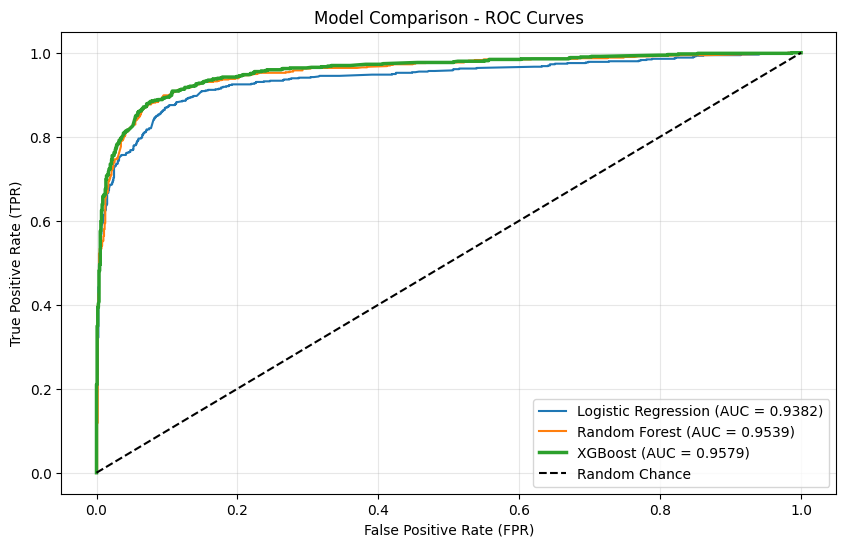

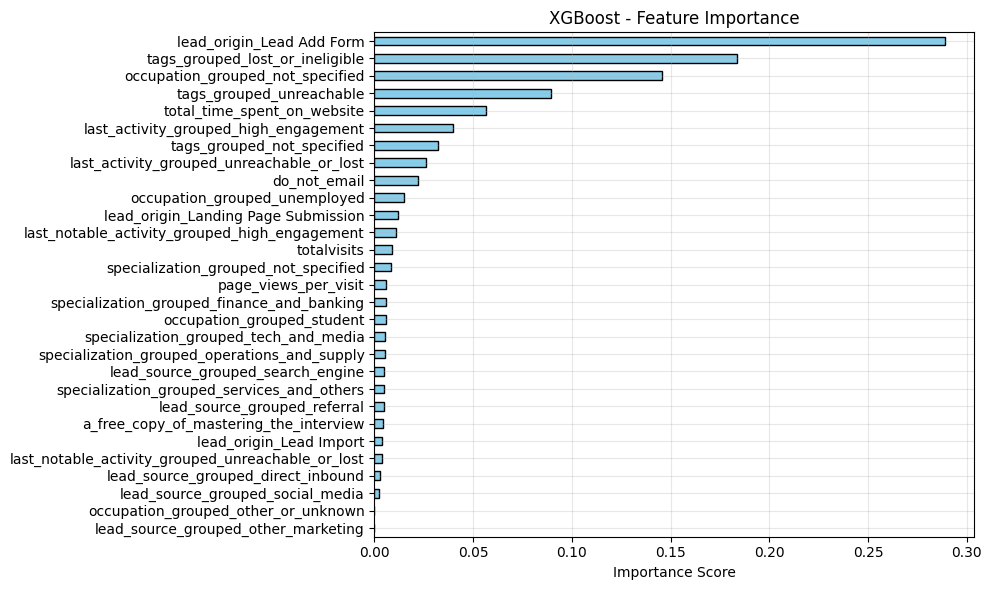

In [ ]:
from sklearn.metrics import roc_curve


# 1. ROC Curve 
plt.figure(figsize=(10, 6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_log):.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.4f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Model Comparison - ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 2. XGBoost Feature Importance
feature_importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [179]:
from sklearn.metrics import precision_recall_curve

#Optimal Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_threshold_idx]

print(f"Optimal Threshold (Max F1): {best_thresh:.3f}")

# 2. Lead Scoring (0 - 100)
df_results = X_test.copy()
df_results['actual_converted'] = y_test
df_results['conversion_proba'] = y_proba_xgb
df_results['lead_score'] = (df_results['conversion_proba'] * 100).round(1)

# Customer Segment
def assign_segment(score):
    if score >= 80:
        return 'Hot Lead'
    elif score >= 50:
        return 'Warm Lead'
    else:
        return 'Cold Lead'

df_results['lead_segment'] = df_results['lead_score'].apply(assign_segment)

# Segment Distrubition
print("\nLead Segment Distrubition:")
print(df_results['lead_segment'].value_counts())

Optimal Threshold (Max F1): 0.409

Lead Segment Distrubition:
lead_segment
Cold Lead    1153
Hot Lead      494
Warm Lead     168
Name: count, dtype: int64


In [181]:
import joblib

joblib.dump(best_xgb, 'xgboost_lead_scoring_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')


['standard_scaler.pkl']